# Day 1 Project: 택시 이용내역 데이터

프로젝트 수행 방법   

이번 프로젝트에서 사용할 데이터 이름은 trip.csv입니다.
다양한 변수들을 활용하여 “택시 요금”을 예측한다는 가정하에 데이터를 정제해보세요.

지금까지 배운 내용을 최대한 활용하여 문제가 되는 부분을 찾아 정리하고, 최대한 변수들을 머신러닝 알고리즘에 활용 가능하도록 만들어봅시다.   
만약 이전에 배웠던 학습 내용이 익숙하지 않다면  이전학습을 다시 한번 복습해 주세요. 🤗


먼저 필요한 라이브러리를 import해 볼까요?   
Step 1. 이것만큼은 꼭 해보세요!   
프로젝트에 정답은 없습니다. 배우신 내용을 토대로 자유롭게 데이터를 정제하되, 아래 내용만큼은 반드시 실습해봅시다.   

결측치 판단 및 처리   
[힌트] 결측치의 유무와 비율을 살펴보고 적절한 방법으로 처리합니다.   
이상치 판단 및 처리   
[힌트] 숫자형 변수 각각에 대해, 데이터의 index와 변수 값 사이의 scatter plot을 그려보고 이상치가 관찰될 경우 제거합니다.   
Step 2. 이런것도 해볼 수 있어요!   
자유롭게 실습을 해보시고, 여유가 되면 아래의 내용도 실습해보세요.   

택시 탑승 및 하차 시간을 활용할 수 있을지 고민해보세요.   
[힌트] 택시의 주행 시간과 주행 거리, 요금 등의 상관 관계도 살펴볼 수 있겠죠?   
Credit Card와 Debit Card를 구분없이 "Card"라는 이름으로 만들어 보세요.   

In [8]:
# 라이브러리 임폴트
import pandas as pd
import numpy as np

# (선택) Jupyter/VSCode 노트북에서 표를 더 예쁘게/인터랙티브하게 보이게 도와줌
try:
    from IPython.display import display
except ImportError:
    display = print  # 만약 IPython이 없으면 print로라도 나오게 처리


In [10]:
#  데이터 불러오기

df = pd.read_csv("../00_Dataset/trip.csv")  # ../00_Dataset/는 노트북 폴더의 상위 폴더에 있는 00_Dataset
print("✅ 데이터 로드 완료!")
print("행/열 크기(shape):", df.shape)
print("-" * 60)

✅ 데이터 로드 완료!
행/열 크기(shape): (22701, 9)
------------------------------------------------------------


In [15]:
df

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.00
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.00
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.00
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.00
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.00
...,...,...,...,...,...,...,...,...,...
22696,Austin Johnson,02/24/2017 5:37:23 PM,02/24/2017 5:40:39 PM,Cash,3,0.61,4.0,0.00,0.00
22697,Monique Williams,08/06/2017 4:43:59 PM,08/06/2017 5:24:47 PM,Cash,1,16.71,52.0,14.64,5.76
22698,Drew Graves,09/04/2017 2:54:14 PM,09/04/2017 2:58:22 PM,Debit Card,1,0.42,4.5,0.00,0.00
22699,Jonathan Copeland,07/15/2017 12:56:30 PM,07/15/2017 1:08:26 PM,Debit Card,1,2.36,10.5,1.70,0.00


In [13]:
data.head()

,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
0,Pamela Duffy,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,Debit Card,6,3.34,13.0,2.76,0.0
1,Michelle Foster,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,Debit Card,1,1.80,16.0,4.00,0.0
2,Tina Combs,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,Debit Card,1,1.00,6.5,1.45,0.0
3,Anthony Ray,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,Cash,1,3.70,20.5,6.39,0.0
4,Brianna Johnson,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,Debit Card,1,4.37,16.5,0.00,0.0


In [10]:
data.head(10)

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,NaN,1,0,113803,S,1,1912-03-28
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,S,0,1912-04-03
5,3,"Moran, Mr. James",male,28.0,0,0,330877,Q,0,1912-03-30
6,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,S,0,1912-03-14
7,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,S,0,1912-03-14
8,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,S,1,1912-01-30
9,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,C,1,1912-03-04


In [11]:
data.head(3)

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23


In [12]:
#DataFrame 또는 Series 객체의 끝에서부터 지정된 수의 행을 반환합니다.
data.tail()

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
880,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,S,0,1912-01-29
881,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,S,1,1912-03-30
882,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,C,1,1912-03-01
884,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,Q,0,1912-03-05


In [13]:
data.tail(10)

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
875,3,"Markun, Mr. Johann",male,33.0,0,0,349257,S,0,1912-03-25
876,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,S,0,1912-02-16
877,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,S,0,1912-03-23
878,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,S,0,1912-01-21
879,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,Q,0,1912-03-28
880,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,S,0,1912-01-29
881,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,S,1,1912-03-30
882,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,C,1,1912-03-01
884,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,Q,0,1912-03-05


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885 entries, 0 to 884
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       885 non-null    int64  
 1   Name         885 non-null    object 
 2   Gendr        885 non-null    object 
 3   Age          879 non-null    float64
 4   SibSp        885 non-null    int64  
 5   Parch        885 non-null    int64  
 6   Ticket       885 non-null    object 
 7   Embarked     883 non-null    object 
 8   Survived     885 non-null    int64  
 9   ticket_date  885 non-null    object 
dtypes: float64(1), int64(4), object(5)
memory usage: 69.3+ KB


In [15]:
#DataFrame 또는 Series 객체에 대한 요약 통계를 제공합니다.
data.describe()

,Pclass,Age,SibSp,Parch,Survived
count,885.000000,879.000000,885.000000,885.000000,885.000000
mean,2.311864,29.679181,0.525424,0.377401,0.377401
std,0.836069,13.559664,1.109746,0.805768,0.485011
min,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,0.000000
50%,3.000000,28.000000,0.000000,0.000000,0.000000
75%,3.000000,35.000000,1.000000,0.000000,1.000000
max,3.000000,145.000000,8.000000,6.000000,1.000000


In [16]:
data

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,NaN,1,0,113803,S,1,1912-03-28
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...,...,...,...
880,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,S,0,1912-01-29
881,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,S,1,1912-03-30
882,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,C,1,1912-03-01


In [17]:
data['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
880                                Montvila, Rev. Juozas
881                         Graham, Miss. Margaret Edith
882             Johnston, Miss. Catherine Helen "Carrie"
883                                Behr, Mr. Karl Howell
884                                  Dooley, Mr. Patrick
Name: Name, Length: 885, dtype: object

In [18]:
data[['Name','Age']]

,Name,Age
0,"Braund, Mr. Owen Harris",22.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0
2,"Heikkinen, Miss. Laina",26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",NaN
4,"Allen, Mr. William Henry",35.0
...,...,...
880,"Montvila, Rev. Juozas",27.0
881,"Graham, Miss. Margaret Edith",19.0
882,"Johnston, Miss. Catherine Helen ""Carrie""",28.0
883,"Behr, Mr. Karl Howell",26.0


In [19]:
pd.DataFrame(data['Name'])

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
880,"Montvila, Rev. Juozas"
881,"Graham, Miss. Margaret Edith"
882,"Johnston, Miss. Catherine Helen ""Carrie"""
883,"Behr, Mr. Karl Howell"


In [20]:
pd.Series(pd.DataFrame(data['Name'])['Name'])

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
880                                Montvila, Rev. Juozas
881                         Graham, Miss. Margaret Edith
882             Johnston, Miss. Catherine Helen "Carrie"
883                                Behr, Mr. Karl Howell
884                                  Dooley, Mr. Patrick
Name: Name, Length: 885, dtype: object

In [21]:
import numpy as np

In [22]:
np.array(data)

array([[3, 'Braund, Mr. Owen Harris', 'male', ..., 'S', 0, '1912-01-12'],
       [1, 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)',
        'female', ..., 'C', 1, '1912-03-29'],
       [3, 'Heikkinen, Miss. Laina', 'female', ..., 'S', 1, '1912-02-23'],
       ...,
       [3, 'Johnston, Miss. Catherine Helen "Carrie"', 'female', ...,
        'S', 0, '1912-04-07'],
       [1, 'Behr, Mr. Karl Howell', 'male', ..., 'C', 1, '1912-03-01'],
       [3, 'Dooley, Mr. Patrick', 'male', ..., 'Q', 0, '1912-03-05']],
      shape=(885, 10), dtype=object)

# 불필요한 컬럼 삭제 (Dropping columns), 누락된 결측치 처리 (Missing values)

In [23]:
import pandas as pd

In [25]:
data = pd.read_csv("../00_Dataset/titanic.csv")

In [ ]:
# 중복 데이터 처리 부분에서 활용
data[data.duplicated()]

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
25,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,S,0,1912-03-14
632,3,"Skoog, Miss. Mabel",female,9.0,3,2,347088,S,0,1912-03-16
714,1,"Endres, Miss. Caroline Louise",female,38.0,0,0,PC 17757,C,1,1912-03-14


In [ ]:
# 중복 데이터 처리 부분에서 활용
data[data['Name'] == 'Palsson, Miss. Torborg Danira']

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
24,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,S,0,1912-03-14
25,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,S,0,1912-03-14


In [ ]:
# 중복 데이터 처리 부분에서 활용
data = data.drop_duplicates()

In [ ]:
data.head()

,Pclass,Name,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,NaN,1,0,113803,S,1,1912-03-28
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,S,0,1912-04-03


In [ ]:
data.drop('Name', axis=1, inplace=True)

In [ ]:
data.head()

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,NaN,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03


In [ ]:
data.drop(2, axis=0)

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
3,1,female,NaN,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03
5,3,male,28.0,0,0,330877,Q,0,1912-03-30
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29
881,1,female,19.0,0,0,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,26.0,0,0,111369,C,1,1912-03-01


In [ ]:
data.drop(['Pclass','Age'], axis=1)

,Gendr,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,male,1,0,A/5 21171,S,0,1912-01-12
1,female,1,0,PC 17599,C,1,1912-03-29
2,female,0,0,STON/O2. 3101282,S,1,1912-02-23
3,female,1,0,113803,S,1,1912-03-28
4,male,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...
880,male,0,0,211536,S,0,1912-01-29
881,female,0,0,112053,S,1,1912-03-30
882,female,1,2,W./C. 6607,S,0,1912-04-07
883,male,0,0,111369,C,1,1912-03-01


In [ ]:
data.loc[[4,5,6]]

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
4,3,male,35.0,0,0,373450,S,0,1912-04-03
5,3,male,28.0,0,0,330877,Q,0,1912-03-30
6,1,male,54.0,0,0,17463,S,0,1912-03-14


In [ ]:
data.loc[4:]

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
4,3,male,35.0,0,0,373450,S,0,1912-04-03
5,3,male,28.0,0,0,330877,Q,0,1912-03-30
6,1,male,54.0,0,0,17463,S,0,1912-03-14
7,3,male,2.0,3,1,349909,S,0,1912-03-14
8,3,female,27.0,0,2,347742,S,1,1912-01-30
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29
881,1,female,19.0,0,0,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,26.0,0,0,111369,C,1,1912-03-01


In [ ]:
data.loc[[4, 5, 6]]

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
4,3,male,35.0,0,0,373450,S,0,1912-04-03
5,3,male,28.0,0,0,330877,Q,0,1912-03-30
6,1,male,54.0,0,0,17463,S,0,1912-03-14


In [ ]:
data.iloc[[4, 5, 6]]

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
4,3,male,35.0,0,0,373450,S,0,1912-04-03
5,3,male,28.0,0,0,330877,Q,0,1912-03-30
6,1,male,54.0,0,0,17463,S,0,1912-03-14


In [ ]:
temp = data.head().copy()

In [ ]:
temp.index = ['a', 'b', 'c', 'd', 'e']

In [ ]:
temp

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
a,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
b,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
c,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
d,1,female,NaN,1,0,113803,S,1,1912-03-28
e,3,male,35.0,0,0,373450,S,0,1912-04-03


In [ ]:
temp.loc['c']

Pclass                        3
Gendr                    female
Age                        26.0
SibSp                         0
Parch                         0
Ticket         STON/O2. 3101282
Embarked                      S
Survived                      1
ticket_date          1912-02-23
Name: c, dtype: object

In [ ]:
temp.iloc[2]

Pclass                        3
Gendr                    female
Age                        26.0
SibSp                         0
Parch                         0
Ticket         STON/O2. 3101282
Embarked                      S
Survived                      1
ticket_date          1912-02-23
Name: c, dtype: object

In [ ]:
data.isna()

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
880,False,False,False,False,False,False,False,False,False
881,False,False,False,False,False,False,False,False,False
882,False,False,False,False,False,False,False,False,False
883,False,False,False,False,False,False,False,False,False


In [ ]:
data.isna().sum()

Pclass         0
Gendr          0
Age            6
SibSp          0
Parch          0
Ticket         0
Embarked       2
Survived       0
ticket_date    0
dtype: int64

In [ ]:
data.isna().mean()

Pclass         0.000000
Gendr          0.000000
Age            0.006803
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Embarked       0.002268
Survived       0.000000
ticket_date    0.000000
dtype: float64

In [ ]:
data[data['Age'].isna()]

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
3,1,female,NaN,1,0,113803,S,1,1912-03-28
106,3,male,NaN,0,0,312991,S,1,1912-01-27
156,3,male,NaN,0,0,SOTON/OQ 392090,S,0,1912-04-01
185,3,female,NaN,1,0,370365,Q,1,1912-03-25
213,3,male,NaN,1,0,367229,Q,0,1912-02-12
241,2,male,NaN,0,0,W./C. 14263,S,0,1912-01-31


In [ ]:
age_na_index = data[data['Age'].isna()].index

In [ ]:
embarked_na_index = data[data['Embarked'].isna()].index

In [ ]:
data.loc[embarked_na_index]

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
15,2,female,55.0,0,0,248706,NaN,1,1912-03-05
322,3,male,28.0,8,2,CA. 2343,NaN,0,1912-03-26


In [ ]:
data

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,NaN,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29
881,1,female,19.0,0,0,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,26.0,0,0,111369,C,1,1912-03-01


In [ ]:
len(data)

882

In [ ]:
data.dropna()

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
4,3,male,35.0,0,0,373450,S,0,1912-04-03
5,3,male,28.0,0,0,330877,Q,0,1912-03-30
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29
881,1,female,19.0,0,0,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,26.0,0,0,111369,C,1,1912-03-01


In [ ]:
data.dropna(subset = ['Embarked'])

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,NaN,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29
881,1,female,19.0,0,0,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,26.0,0,0,111369,C,1,1912-03-01


In [ ]:
data['Age'].mean()

np.float64(29.718036529680365)

In [ ]:
data['Age'].median()

28.0

In [ ]:
data['Age'] = data['Age'].fillna(data['Age'].median())

In [ ]:
data.loc[age_na_index]

,Pclass,Gendr,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
3,1,female,28.0,1,0,113803,S,1,1912-03-28
106,3,male,28.0,0,0,312991,S,1,1912-01-27
156,3,male,28.0,0,0,SOTON/OQ 392090,S,0,1912-04-01
185,3,female,28.0,1,0,370365,Q,1,1912-03-25
213,3,male,28.0,1,0,367229,Q,0,1912-02-12
241,2,male,28.0,0,0,W./C. 14263,S,0,1912-01-31


In [ ]:
data['Embarked'].value_counts()

Embarked
S    638
C    165
Q     77
Name: count, dtype: int64

In [ ]:
640/885

0.7231638418079096

In [ ]:
data['Embarked'] = data['Embarked'].fillna('S')

In [ ]:
data.drop('Age', axis=1)

,Pclass,Gendr,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,1,0,A/5 21171,S,0,1912-01-12
1,1,female,1,0,PC 17599,C,1,1912-03-29
2,3,female,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,1,0,113803,S,1,1912-03-28
4,3,male,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...,...
880,2,male,0,0,211536,S,0,1912-01-29
881,1,female,0,0,112053,S,1,1912-03-30
882,3,female,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,0,0,111369,C,1,1912-03-01


# 이상치 탐지 및 처리 (Outliers)

In [ ]:
data.describe()

,Pclass,Age,SibSp,Parch,Survived
count,882.000000,882.000000,882.000000,882.000000,882.000000
mean,2.311791,29.706349,0.520408,0.375283,0.377551
std,0.835681,13.496645,1.105210,0.804909,0.485049
min,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,0.000000
50%,3.000000,28.000000,0.000000,0.000000,0.000000
75%,3.000000,35.000000,1.000000,0.000000,1.000000
max,3.000000,145.000000,8.000000,6.000000,1.000000


In [ ]:
data['Age'].sort_values()

379      1.0
785      1.0
171      1.0
823      1.0
182      1.0
       ...  
490     71.0
845     74.0
627     80.0
279     97.0
321    145.0
Name: Age, Length: 882, dtype: float64

In [ ]:
data['SibSp'].sort_values().tail(15)

277    4
170    4
844    4
384    5
71     5
477    5
60     5
680    5
158    8
322    8
840    8
857    8
200    8
789    8
179    8
Name: SibSp, dtype: int64

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

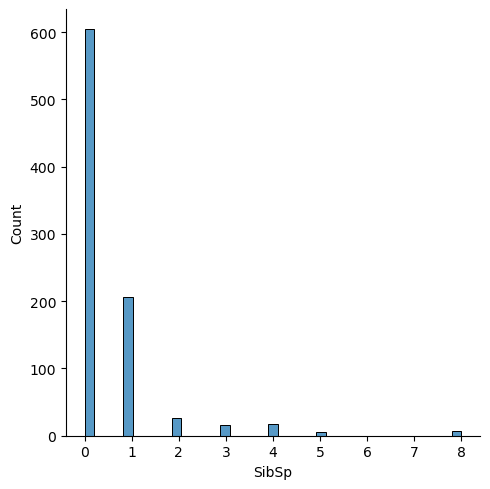

In [ ]:
sns.displot(data['SibSp'])

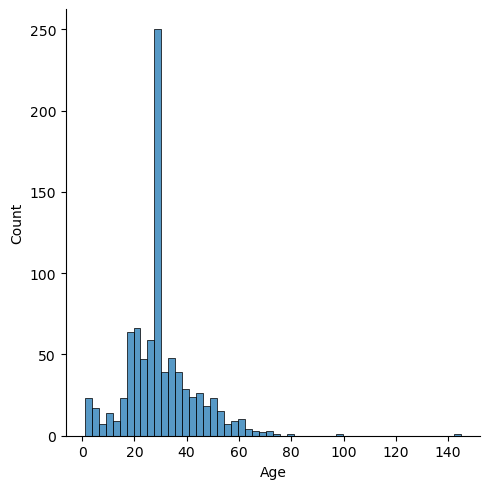

In [ ]:
sns.displot(data['Age'])

<Axes: xlabel='None', ylabel='Age'>

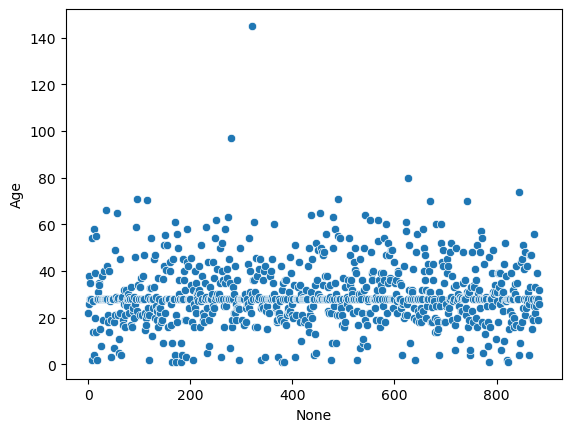

In [ ]:
sns.scatterplot(x = data.index, y = data['Age'])

<Axes: xlabel='None', ylabel='SibSp'>

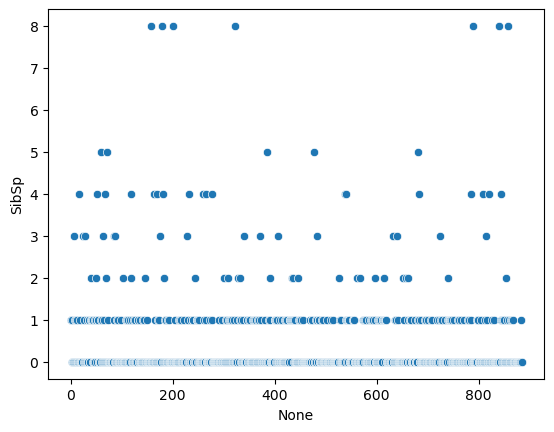

In [ ]:
sns.scatterplot(x = data.index, y = data['SibSp'])

<Axes: ylabel='Age'>

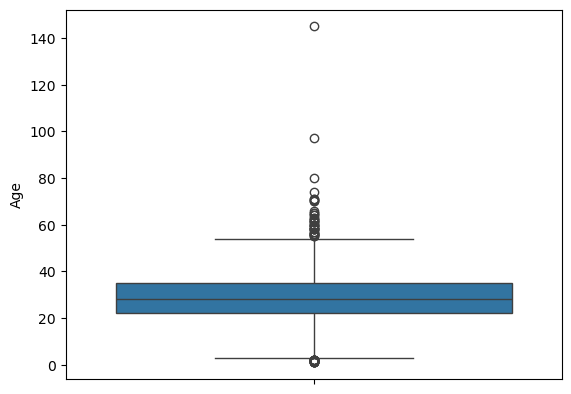

In [ ]:
sns.boxplot(data['Age'])

In [ ]:
#IQR = 75% - 25%
#IQR * 1.5

In [ ]:
data.describe()

,Pclass,Age,SibSp,Parch,Survived
count,882.000000,882.000000,882.000000,882.000000,882.000000
mean,2.311791,29.706349,0.520408,0.375283,0.377551
std,0.835681,13.496645,1.105210,0.804909,0.485049
min,1.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,0.000000
50%,3.000000,28.000000,0.000000,0.000000,0.000000
75%,3.000000,35.000000,1.000000,0.000000,1.000000
max,3.000000,145.000000,8.000000,6.000000,1.000000


In [ ]:
data = data[data['Age'] <= 100]

In [ ]:
data['Age'].sort_values()

171     1.0
384     1.0
182     1.0
379     1.0
823     1.0
       ... 
95     71.0
490    71.0
845    74.0
627    80.0
279    97.0
Name: Age, Length: 881, dtype: float64

In [ ]:
data['Age'].sort_values()

171     1.0
384     1.0
182     1.0
379     1.0
823     1.0
       ... 
95     71.0
490    71.0
845    74.0
627    80.0
279    97.0
Name: Age, Length: 881, dtype: float64

In [ ]:
def age_func(x):
  if x > 80:
    return 80
  else:
    return x

In [ ]:
data['Age']= data['Age'].apply(age_func)

/var/folders/zx/5ql37vbd32l6kwdp9gj2844m0000gn/T/ipykernel_92195/2040822203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age']= data['Age'].apply(age_func)


In [ ]:
data['Age'].sort_values()

171     1.0
384     1.0
182     1.0
379     1.0
823     1.0
       ... 
95     71.0
490    71.0
845    74.0
627    80.0
279    80.0
Name: Age, Length: 881, dtype: float64

In [ ]:
def new_age_func(x):
  if x > 70:
    return 70
  else:
    return x

In [ ]:
data['Age'].apply(new_age_func)

0      22.0
1      38.0
2      26.0
3      28.0
4      35.0
       ... 
880    27.0
881    19.0
882    28.0
883    26.0
884    32.0
Name: Age, Length: 881, dtype: float64

In [ ]:
data['Age'].apply(lambda x: 70 if x>70 else x)

0      22.0
1      38.0
2      26.0
3      28.0
4      35.0
       ... 
880    27.0
881    19.0
882    28.0
883    26.0
884    32.0
Name: Age, Length: 881, dtype: float64


# 중복 데이터 처리 및 데이터 형태 변환처리(Removing duplicate data, apply, map, replace, rename)

In [ ]:
data = data.rename({'Gendr': 'Gender'}, axis = 1)

In [ ]:
data.rename({0: 'a', 1: 'b', 2: 'c'})

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
a,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
b,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
c,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,28.0,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29
881,1,female,19.0,0,0,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07
883,1,male,26.0,0,0,111369,C,1,1912-03-01


In [ ]:
data['Embarked'].replace({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})

0      Southampton
1        Cherbourg
2      Southampton
3      Southampton
4      Southampton
          ...     
880    Southampton
881    Southampton
882    Southampton
883      Cherbourg
884     Queenstown
Name: Embarked, Length: 881, dtype: object

In [ ]:
data.replace({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,Southampton,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,Cherbourg,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,Southampton,1,1912-02-23
3,1,female,28.0,1,0,113803,Southampton,1,1912-03-28
4,3,male,35.0,0,0,373450,Southampton,0,1912-04-03
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,Southampton,0,1912-01-29
881,1,female,19.0,0,0,112053,Southampton,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,Southampton,0,1912-04-07
883,1,male,26.0,0,0,111369,Cherbourg,1,1912-03-01


In [ ]:
data.replace({0: 999})

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,999,A/5 21171,S,999,1912-01-12
1,1,female,38.0,1,999,PC 17599,C,1,1912-03-29
2,3,female,26.0,999,999,STON/O2. 3101282,S,1,1912-02-23
3,1,female,28.0,1,999,113803,S,1,1912-03-28
4,3,male,35.0,999,999,373450,S,999,1912-04-03
...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,999,999,211536,S,999,1912-01-29
881,1,female,19.0,999,999,112053,S,1,1912-03-30
882,3,female,28.0,1,2,W./C. 6607,S,999,1912-04-07
883,1,male,26.0,999,999,111369,C,1,1912-03-01


In [ ]:
data['Gender'].map(len)

0      4
1      6
2      6
3      6
4      4
      ..
880    4
881    6
882    6
883    4
884    4
Name: Gender, Length: 881, dtype: int64

In [ ]:
data.apply(len)

Pclass         881
Gender         881
Age            881
SibSp          881
Parch          881
Ticket         881
Embarked       881
Survived       881
ticket_date    881
dtype: int64

# 텍스트 처리 (Text handling)

In [ ]:
data.head()

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,28.0,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 0 to 884
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       881 non-null    int64  
 1   Gender       881 non-null    object 
 2   Age          881 non-null    float64
 3   SibSp        881 non-null    int64  
 4   Parch        881 non-null    int64  
 5   Ticket       881 non-null    object 
 6   Embarked     881 non-null    object 
 7   Survived     881 non-null    int64  
 8   ticket_date  881 non-null    object 
dtypes: float64(1), int64(4), object(4)
memory usage: 101.1+ KB


In [ ]:
sample_txt = 'A/5 21171'

In [ ]:
sample_txt

'A/5 21171'

In [ ]:
sample_txt[0:3]

'A/5'

In [ ]:
sample_txt[:3]

'A/5'

In [ ]:
sample_txt[4:11]

'21171'

In [ ]:
sample_txt[4:]

'21171'

In [ ]:
sample_txt[-5:]

'21171'

In [ ]:
sample_txt.lower()

'a/5 21171'

In [ ]:
sample_txt.upper()

'A/5 21171'

In [ ]:
sample_txt.lower().upper()

'A/5 21171'

In [ ]:
sample_txt.split()

['A/5', '21171']

In [ ]:
sample_txt.split('/')

['A', '5 21171']

In [ ]:
sample_txt.split()[-1]

'21171'

In [ ]:
new_txt = ' A/5 21171'

In [ ]:
new_txt

' A/5 21171'

In [ ]:
new_txt.strip()

'A/5 21171'

In [ ]:
data['Ticket'][:3]

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
Name: Ticket, dtype: object

In [ ]:
data.head()

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23
3,1,female,28.0,1,0,113803,S,1,1912-03-28
4,3,male,35.0,0,0,373450,S,0,1912-04-03


In [ ]:
data['Ticket'].str[-5:]

0      21171
1      17599
2      01282
3      13803
4      73450
       ...  
880    11536
881    12053
882     6607
883    11369
884    70376
Name: Ticket, Length: 881, dtype: object

In [ ]:
data['Ticket'].str.split(expand = True)

,0,1,2
0,A/5,21171,None
1,PC,17599,None
2,STON/O2.,3101282,None
3,113803,None,None
4,373450,None,None
...,...,...,...
880,211536,None,None
881,112053,None,None
882,W./C.,6607,None
883,111369,None,None


In [ ]:
data['new_ticket'] = data['Ticket'].str.split().apply(lambda x: x[-1])

In [ ]:
data

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date,new_ticket
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12,21171
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29,17599
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23,3101282
3,1,female,28.0,1,0,113803,S,1,1912-03-28,113803
4,3,male,35.0,0,0,373450,S,0,1912-04-03,373450
...,...,...,...,...,...,...,...,...,...,...
880,2,male,27.0,0,0,211536,S,0,1912-01-29,211536
881,1,female,19.0,0,0,112053,S,1,1912-03-30,112053
882,3,female,28.0,1,2,W./C. 6607,S,0,1912-04-07,6607
883,1,male,26.0,0,0,111369,C,1,1912-03-01,111369


In [ ]:
txt_a = '123'
txt_b = 'abc'
txt_c = '12a'

In [ ]:
txt_a.isdigit()

True

In [ ]:
txt_b.isdigit()

False

In [ ]:
txt_c.isdigit()

False

In [ ]:
data[~data['new_ticket'].str.isdigit()]

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date,new_ticket
178,3,male,36.0,0,0,LINE,S,0,1912-04-08,LINE
270,3,male,25.0,0,0,LINE,S,1,1912-04-08,LINE
301,3,male,19.0,0,0,LINE,S,0,1912-04-08,LINE
594,3,male,49.0,0,0,LINE,S,0,1912-04-08,LINE


In [ ]:
data['new_ticket'] = data['new_ticket'].replace({'LINE': '999999'})

In [ ]:
data[~data['new_ticket'].str.isdigit()]

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date,new_ticket


In [ ]:
data['new_ticket'].astype('int')

0        21171
1        17599
2      3101282
3       113803
4       373450
        ...   
880     211536
881     112053
882       6607
883     111369
884     370376
Name: new_ticket, Length: 881, dtype: int64

In [ ]:
data['new_ticket'] = pd.to_numeric(data['new_ticket'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 0 to 884
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       881 non-null    int64  
 1   Gender       881 non-null    object 
 2   Age          881 non-null    float64
 3   SibSp        881 non-null    int64  
 4   Parch        881 non-null    int64  
 5   Ticket       881 non-null    object 
 6   Embarked     881 non-null    object 
 7   Survived     881 non-null    int64  
 8   ticket_date  881 non-null    object 
 9   new_ticket   881 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 108.0+ KB


# 날짜 및 시간 데이터 처리 (Datetime)

In [ ]:
data.head()

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date,new_ticket
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12,21171
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29,17599
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23,3101282
3,1,female,28.0,1,0,113803,S,1,1912-03-28,113803
4,3,male,35.0,0,0,373450,S,0,1912-04-03,373450


In [ ]:
from datetime import datetime

In [ ]:
sample_date = datetime.strptime('2023-01-01', '%Y-%m-%d')

In [ ]:
datetime.strftime(sample_date, '%Y-%m-%d')

'2023-01-01'

In [ ]:
sample_date.hour

0

In [ ]:
next_date = datetime.strptime('2023-05-05', '%Y-%m-%d')

In [ ]:
next_date - sample_date

datetime.timedelta(days=124)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 0 to 884
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pclass       881 non-null    int64  
 1   Gender       881 non-null    object 
 2   Age          881 non-null    float64
 3   SibSp        881 non-null    int64  
 4   Parch        881 non-null    int64  
 5   Ticket       881 non-null    object 
 6   Embarked     881 non-null    object 
 7   Survived     881 non-null    int64  
 8   ticket_date  881 non-null    object 
 9   new_ticket   881 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 108.0+ KB


In [ ]:
data['ticket_date'] = pd.to_datetime(data['ticket_date'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 0 to 884
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Pclass       881 non-null    int64         
 1   Gender       881 non-null    object        
 2   Age          881 non-null    float64       
 3   SibSp        881 non-null    int64         
 4   Parch        881 non-null    int64         
 5   Ticket       881 non-null    object        
 6   Embarked     881 non-null    object        
 7   Survived     881 non-null    int64         
 8   ticket_date  881 non-null    datetime64[ns]
 9   new_ticket   881 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 108.0+ KB


In [ ]:
data['ticket_date'].dt.day

0      12
1      29
2      23
3      28
4       3
       ..
880    29
881    30
882     7
883     1
884     5
Name: ticket_date, Length: 881, dtype: int32

In [ ]:
acc = datetime.strptime('1912-04-15', '%Y-%m-%d')

In [ ]:
data['buy_before'] = acc - data['ticket_date']

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 0 to 884
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype          
---  ------       --------------  -----          
 0   Pclass       881 non-null    int64          
 1   Gender       881 non-null    object         
 2   Age          881 non-null    float64        
 3   SibSp        881 non-null    int64          
 4   Parch        881 non-null    int64          
 5   Ticket       881 non-null    object         
 6   Embarked     881 non-null    object         
 7   Survived     881 non-null    int64          
 8   ticket_date  881 non-null    datetime64[ns] 
 9   new_ticket   881 non-null    int64          
 10  buy_before   881 non-null    timedelta64[ns]
dtypes: datetime64[ns](1), float64(1), int64(5), object(3), timedelta64[ns](1)
memory usage: 114.9+ KB


In [ ]:
data.head()

,Pclass,Gender,Age,SibSp,Parch,Ticket,Embarked,Survived,ticket_date,new_ticket,buy_before
0,3,male,22.0,1,0,A/5 21171,S,0,1912-01-12,21171,94 days
1,1,female,38.0,1,0,PC 17599,C,1,1912-03-29,17599,17 days
2,3,female,26.0,0,0,STON/O2. 3101282,S,1,1912-02-23,3101282,52 days
3,1,female,28.0,1,0,113803,S,1,1912-03-28,113803,18 days
4,3,male,35.0,0,0,373450,S,0,1912-04-03,373450,12 days


In [ ]:
data['buy_before'] = data['buy_before'].dt.days

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 881 entries, 0 to 884
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Pclass       881 non-null    int64         
 1   Gender       881 non-null    object        
 2   Age          881 non-null    float64       
 3   SibSp        881 non-null    int64         
 4   Parch        881 non-null    int64         
 5   Ticket       881 non-null    object        
 6   Embarked     881 non-null    object        
 7   Survived     881 non-null    int64         
 8   ticket_date  881 non-null    datetime64[ns]
 9   new_ticket   881 non-null    int64         
 10  buy_before   881 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(3)
memory usage: 114.9+ KB


In [ ]:
data['buy_before'] + 10

0      104
1       27
2       62
3       28
4       22
      ... 
880     87
881     26
882     18
883     55
884     51
Name: buy_before, Length: 881, dtype: int64